In [64]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
from Clustering import find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, fit_dbscan, compare_models, _initialize_som_weights, _find_bmu, _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, get_som_cluster_labels, assign_som_clusters
from sklearn.cluster import MeanShift, estimate_bandwidth 
from Preprocessing import preprocess_data_standardscaler,  preprocess_data_robustscaler, preprocess_data_minmaxscaler, cluster_analysis

In [13]:
df = pd.read_csv('customer_info_engineered.csv')
df_processed_st = preprocess_data_standardscaler(df)
df_processed_rb = preprocess_data_robustscaler(df)
df_processed_mm = preprocess_data_minmaxscaler(df)

In [14]:
healthy_options = [
    'lifetime_spend_vegetables', 
    'lifetime_spend_meat', 
    'lifetime_spend_fish',
    'lifetime_spend_alcohol_drinks', 
    'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_videogames', 
    'typical_hour', 
    'age'
]

df_saude_st = df_processed_st[healthy_options]
df_saude_rb = df_processed_rb[healthy_options]
df_saude_mm = df_processed_mm[healthy_options]

In [15]:
df_cluster_anaylsis = cluster_analysis(df)

# Clustering with Standart Scaler 

## K-Means 

k=2 | Inertia: 196156.34 | Silhouette: 0.3089
k=3 | Inertia: 155459.03 | Silhouette: 0.2547
k=4 | Inertia: 140629.55 | Silhouette: 0.2207
k=5 | Inertia: 129296.04 | Silhouette: 0.2173
k=6 | Inertia: 122003.09 | Silhouette: 0.2161
k=7 | Inertia: 114996.78 | Silhouette: 0.1983
k=8 | Inertia: 109221.32 | Silhouette: 0.1805
k=9 | Inertia: 104915.23 | Silhouette: 0.1792
k=10 | Inertia: 100774.46 | Silhouette: 0.1813


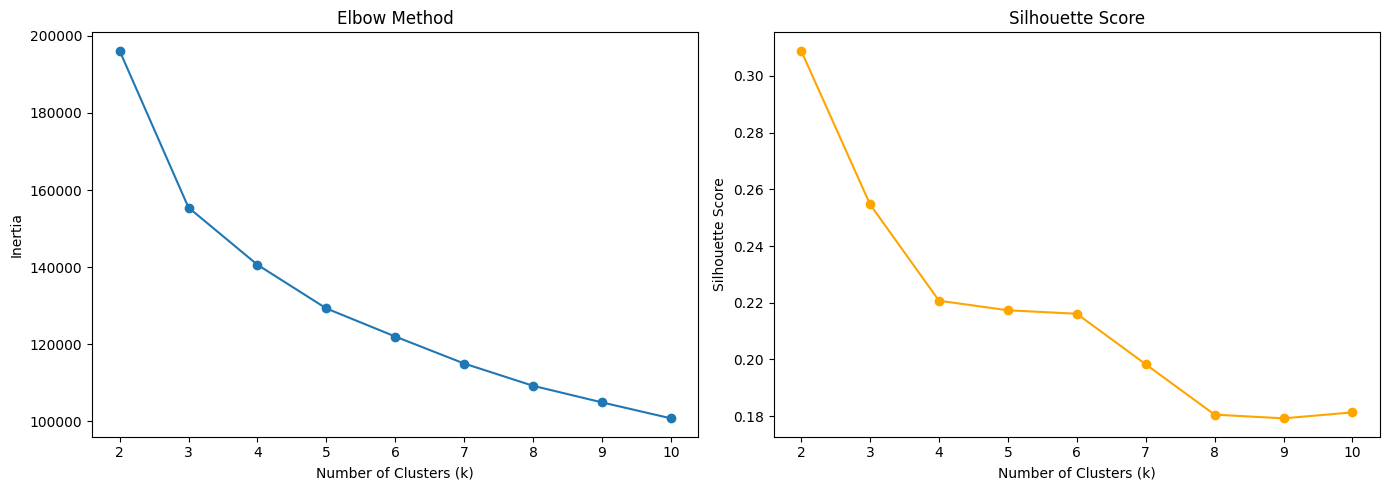

In [16]:
inertias, silhouette_scores = find_optimal_k(df_saude_st)

### K-Means

In [17]:
"""# Determine best k from previous search if available, otherwise default to 5
try:
    ks = list(range(2, 2 + len(silhouette_scores)))
    best_k = ks[int(np.argmax(silhouette_scores))]
except Exception:
    best_k = 5

print(f"Selected k: {best_k}")"""

'# Determine best k from previous search if available, otherwise default to 5\ntry:\n    ks = list(range(2, 2 + len(silhouette_scores)))\n    best_k = ks[int(np.argmax(silhouette_scores))]\nexcept Exception:\n    best_k = 5\n\nprint(f"Selected k: {best_k}")'

In [18]:
print(fit_kmeans(df_saude_st, 5))


Silhouette Score: 0.2173
Cluster sizes:
0    6422
1    6104
2    6889
3    8036
4    5587
Name: count, dtype: int64
                                  cluster_0  cluster_1  cluster_2  cluster_3  \
lifetime_spend_vegetables         -0.261609  -0.547849   1.608872  -0.250190   
lifetime_spend_meat                0.365726   0.170109  -1.635849   0.705798   
lifetime_spend_fish                0.108528  -0.013242  -1.379236   0.772180   
lifetime_spend_alcohol_drinks     -0.954859  -0.040078  -0.551163   0.795881   
lifetime_spend_nonalcohol_drinks  -0.797258  -0.919912   0.331614   0.813204   
lifetime_spend_videogames         -0.479168  -0.596589  -0.381933   0.466863   
typical_hour                      -0.243360  -0.380007  -0.024509  -0.477562   
age                                0.643623  -1.062046   0.131774   0.210057   

                                  cluster_4  
lifetime_spend_vegetables         -0.724695  
lifetime_spend_meat                0.395656  
lifetime_spend_fish      

In [67]:
mean_shift_st = MeanShift(bin_seeding=True)
labels_ms_st = mean_shift_st.fit_predict(df_saude_st)
print("Standard Scaler MeanShift cluster count:", len(np.unique(labels_ms_st)))
if len(np.unique(labels_ms_st)) > 1:
    print(f"Standard Scaler MeanShift silhouette: {silhouette_score(df_saude_st, labels_ms_st):.4f}")
else:
    print("Standard Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_st).value_counts().sort_index())

Standard Scaler MeanShift cluster count: 1
Standard Scaler MeanShift silhouette: not defined (single cluster)
0    33038
Name: count, dtype: int64


## Hierarchical Clustering

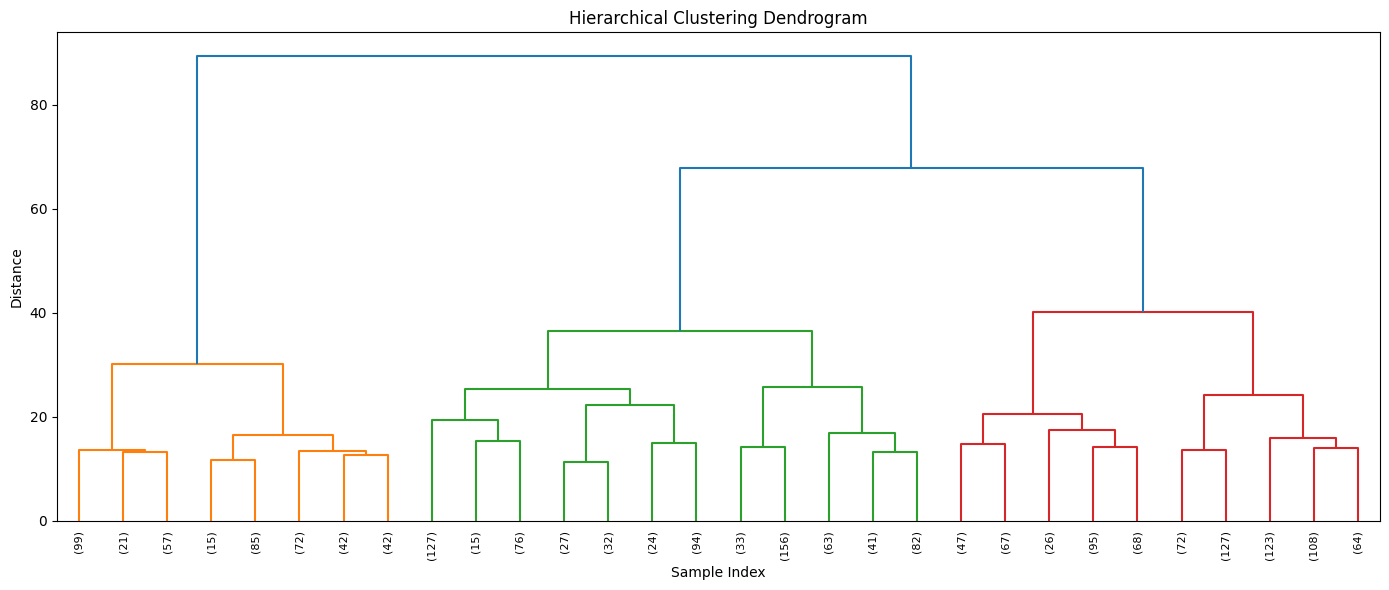

Silhouette Score: 0.1756
Cluster sizes:
0    7521
1    7008
2    8140
3    7023
4    3346
Name: count, dtype: int64
(AgglomerativeClustering(n_clusters=5), array([1, 1, 4, ..., 1, 3, 0], shape=(33038,)))


In [19]:
print(fit_hierarchical(df_saude_st, 5, method='ward'))

## DBSCAN 

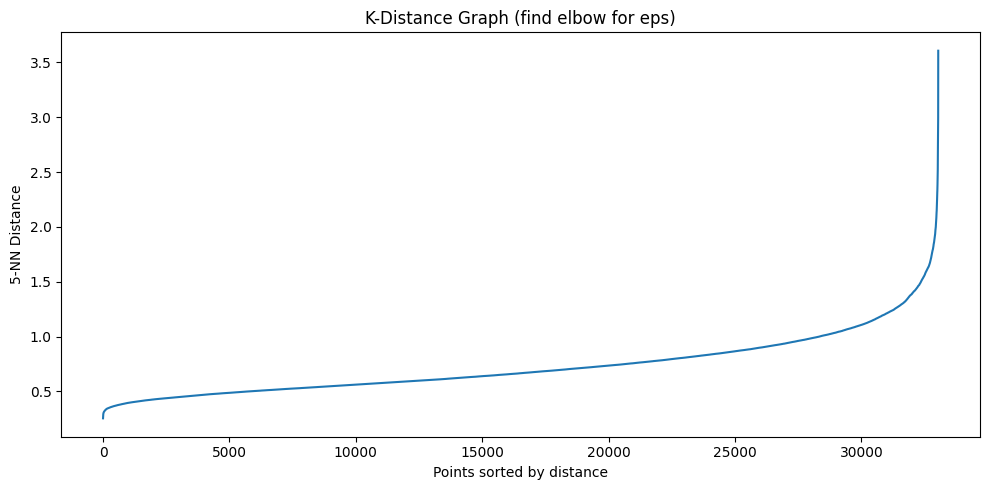

None


In [20]:
print(find_optimal_eps(df_saude_st, n_neighbors=5))

In [21]:
print(fit_dbscan(df_saude_st, 2.5, min_samples=5)) 

Number of clusters: 1
Noise points: 7 (0.02%)
Cluster sizes:
-1        7
 0    33031
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [22]:
print(fit_dbscan(df_saude_st, 3, min_samples=5)) 

Number of clusters: 1
Noise points: 1 (0.00%)
Cluster sizes:
-1        1
 0    33037
Name: count, dtype: int64
(DBSCAN(eps=3), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [23]:
print(fit_dbscan(df_saude_st, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## Self-Organizing Map (SOM)

In [24]:
# Weights initialization  
initial_weights = _initialize_som_weights(df_saude_st, map_shape=(30, 30), random_state=42)

# 2. Find the BMU for all customers
all_bmus = [_find_bmu(initial_weights, row) for row in df_saude_st.values]

# 3. Print the coordinates for the first 5 customers to check the result
print(all_bmus[:5])

[(np.int64(24), np.int64(22)), (np.int64(3), np.int64(3)), (np.int64(27), np.int64(11)), (np.int64(7), np.int64(2)), (np.int64(7), np.int64(2))]


In [25]:
print(_som_learning_rate(initial_lr = 0.1, iteration = 100, n_iterations = 1000))

0.09048374180359596


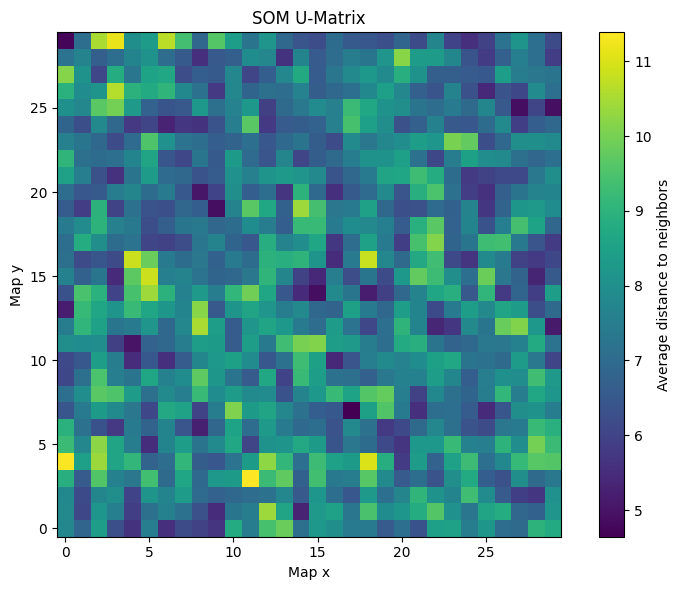

[[ 7.75224186  6.83783868  8.40487822  6.29544531  5.62339005  7.52503846
   5.56313279  6.22170966  5.93952872  5.68337049  8.80272618  7.48731228
   9.41496345  9.84003463  7.12845879  8.24797258  7.988975    7.39136228
   7.45446402  6.58864132  7.1069159   6.34324549  8.45086473  8.50489888
   7.51274225  8.21634108  7.06155878  6.98013046  9.0066903   8.76861392]
 [ 7.82870624  6.10623266  8.18168325  7.56384316  5.88696674  7.12401221
   7.61868981  7.19445067  6.32019951  5.50664756  7.25256039  7.4977813
  10.40216655  8.58972896  5.30945555  8.28166296  8.49955498  7.28416878
   9.44552665  7.91684171  8.19780697  8.8110854   9.57641009  8.04850838
   7.28756955  8.57038072  8.83138617  6.86982423  6.73920608  8.15772376]
 [ 7.7938012   6.16601935  7.74163171  7.96481071  5.98827543  8.12932423
   7.69786086  8.33877187  6.99540956  6.77188129  6.91551356  7.05754161
   7.18830551  7.75417201  6.51921293  8.17411927  7.09102368  6.46474939
   8.29395435  7.10816603  7.70426033

In [26]:
print(plot_som_u_matrix(initial_weights))

In [27]:
print(fit_som(df_saude_st, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, sigma=None, random_state=42, plot_u_matrix=False))

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100
{'weights': array([[[-3.72194566e-02,  9.06718819e-01,  7.81536114e-01,
          1.21385947e+00,  6.37353244e-01,  9.21051018e-01,
         -7.18834527e-01,  7.34556576e-02],
        [-7.31875998e-02,  9.10451961e-01,  7.48452488e-01,
          1.17990404e+00,  6.55253343e-01,  9.22063511e-01,
         -7.24908574e-01,  6.94561788e-01],
        [ 2.95346424e-02,  8.88451300e-01,  7.56345878e-01,
          1.14791304e+00,  8.59873477e-01,  7.79203403e-01,
         -6.80481977e-01,  1.04271623e+00],
        [-1.97398699e-01,  6.68802773e-01,  7.90482169e-01,
          1.04312816e+00,  9.94753788e-01,  6.82177933e-01,
         -5.62762227e-01,  1.02355856e+00],
        [-4.08205753e-01,  4.64741261e-01,  7.52535763e-01,
          8.90951141e-01,  9.69478133e-01,  5.16061976e-01,
         -1.90853173e-01,  9.05483052e-01],
        [-4.85274915e-01,  4.66676537e-01,  7.04325929e-01,
          7.18355473e-01, 

In [28]:
print(get_som_cluster_labels(initial_weights, n_clusters=5, random_state=42))

[[0 3 1 4 4 3 2 2 4 4 4 0 1 4 3 4 1 4 2 0 2 0 3 2 3 4 0 4 2 3]
 [3 1 0 4 4 2 2 1 0 4 3 3 0 2 3 2 4 3 0 2 3 0 1 0 4 4 1 1 0 4]
 [4 1 3 0 4 0 0 1 2 4 1 0 4 4 2 3 3 2 3 2 3 1 4 0 3 2 0 4 0 2]
 [0 4 4 3 4 2 3 0 3 4 0 2 4 2 3 4 3 3 0 0 4 0 2 4 0 0 4 4 1 1]
 [2 4 3 4 1 2 3 3 1 0 0 4 1 0 2 3 0 4 2 4 4 4 0 3 4 4 0 2 0 4]
 [0 1 4 2 4 4 4 0 0 4 3 1 4 0 1 0 3 4 2 2 4 0 2 2 3 4 3 1 2 0]
 [4 3 1 2 3 2 3 3 4 4 1 2 1 0 1 1 3 1 0 0 0 1 4 4 3 4 4 4 4 1]
 [4 0 3 2 0 1 2 0 0 0 4 3 4 1 2 3 2 1 1 4 0 0 3 3 0 0 1 2 3 3]
 [4 3 4 0 1 2 1 2 1 0 0 4 2 3 1 1 4 2 0 2 2 1 2 0 0 4 3 1 1 0]
 [2 2 3 4 0 4 1 4 4 0 4 0 3 3 2 0 1 3 3 4 4 2 4 0 0 1 4 1 2 0]
 [1 0 0 3 1 0 3 3 1 4 2 4 4 1 0 1 1 2 4 0 1 3 0 2 0 0 3 3 4 2]
 [0 3 2 2 3 0 3 1 4 3 4 2 4 2 1 4 1 4 1 1 0 1 0 3 1 4 2 4 1 4]
 [2 1 4 2 4 0 3 2 3 4 0 0 1 0 2 0 3 4 1 1 3 3 2 2 0 1 3 2 0 0]
 [4 0 4 1 4 3 3 2 0 2 1 1 4 2 2 4 4 4 1 0 4 1 2 2 2 3 4 0 1 2]
 [0 2 0 0 0 3 2 1 3 0 2 0 0 4 3 3 2 0 1 1 2 2 2 0 3 3 4 3 2 3]
 [2 3 1 1 2 4 4 4 4 0 4 0 2 0 3 3 1 4 0 4 4 3 0 4 3 4 2

In [29]:
print(assign_som_clusters(initial_weights, df_saude_st,n_clusters=5))

(array([1, 3, 3, ..., 3, 3, 1], shape=(33038,), dtype=int32), array([[0, 3, 1, 4, 4, 3, 2, 2, 4, 4, 4, 0, 1, 4, 3, 4, 1, 4, 2, 0, 2, 0,
        3, 2, 3, 4, 0, 4, 2, 3],
       [3, 1, 0, 4, 4, 2, 2, 1, 0, 4, 3, 3, 0, 2, 3, 2, 4, 3, 0, 2, 3, 0,
        1, 0, 4, 4, 1, 1, 0, 4],
       [4, 1, 3, 0, 4, 0, 0, 1, 2, 4, 1, 0, 4, 4, 2, 3, 3, 2, 3, 2, 3, 1,
        4, 0, 3, 2, 0, 4, 0, 2],
       [0, 4, 4, 3, 4, 2, 3, 0, 3, 4, 0, 2, 4, 2, 3, 4, 3, 3, 0, 0, 4, 0,
        2, 4, 0, 0, 4, 4, 1, 1],
       [2, 4, 3, 4, 1, 2, 3, 3, 1, 0, 0, 4, 1, 0, 2, 3, 0, 4, 2, 4, 4, 4,
        0, 3, 4, 4, 0, 2, 0, 4],
       [0, 1, 4, 2, 4, 4, 4, 0, 0, 4, 3, 1, 4, 0, 1, 0, 3, 4, 2, 2, 4, 0,
        2, 2, 3, 4, 3, 1, 2, 0],
       [4, 3, 1, 2, 3, 2, 3, 3, 4, 4, 1, 2, 1, 0, 1, 1, 3, 1, 0, 0, 0, 1,
        4, 4, 3, 4, 4, 4, 4, 1],
       [4, 0, 3, 2, 0, 1, 2, 0, 0, 0, 4, 3, 4, 1, 2, 3, 2, 1, 1, 4, 0, 0,
        3, 3, 0, 0, 1, 2, 3, 3],
       [4, 3, 4, 0, 1, 2, 1, 2, 1, 0, 0, 4, 2, 3, 1, 1, 4, 2, 0, 2, 2, 1,
        

## Clustering with Robust Scaler

## K-Means 

k=2 | Inertia: 117056.31 | Silhouette: 0.3719
k=3 | Inertia: 89439.53 | Silhouette: 0.2813
k=4 | Inertia: 82371.56 | Silhouette: 0.2331
k=5 | Inertia: 75613.84 | Silhouette: 0.2314
k=6 | Inertia: 70528.77 | Silhouette: 0.2067
k=7 | Inertia: 65797.17 | Silhouette: 0.2128
k=8 | Inertia: 62715.77 | Silhouette: 0.2087
k=9 | Inertia: 59712.98 | Silhouette: 0.2008
k=10 | Inertia: 57879.49 | Silhouette: 0.1918


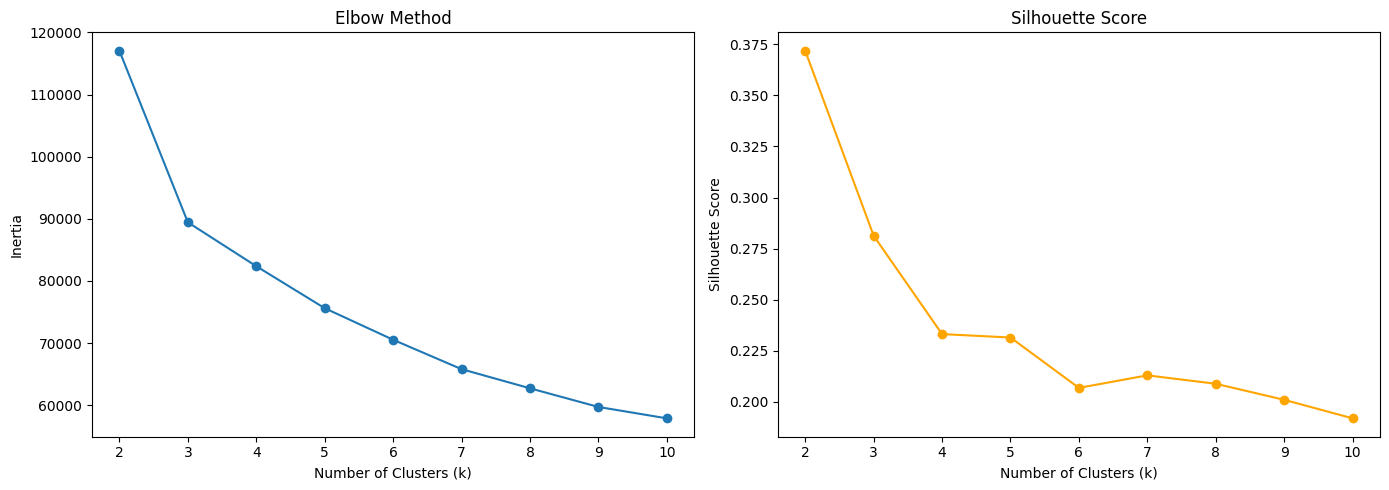

In [30]:
inertias, silhouette_scores = find_optimal_k(df_saude_rb)

### K-Means

In [31]:
"""# Determine best k from previous search if available, otherwise default to 5
try:
    ks = list(range(2, 2 + len(silhouette_scores)))
    best_k = ks[int(np.argmax(silhouette_scores))]
except Exception:
    best_k = 5

print(f"Selected k: {best_k}")"""

'# Determine best k from previous search if available, otherwise default to 5\ntry:\n    ks = list(range(2, 2 + len(silhouette_scores)))\n    best_k = ks[int(np.argmax(silhouette_scores))]\nexcept Exception:\n    best_k = 5\n\nprint(f"Selected k: {best_k}")'

In [32]:
print(fit_kmeans(df_saude_rb, 5))


Silhouette Score: 0.2314
Cluster sizes:
0     8960
1     2995
2     6532
3     4349
4    10202
Name: count, dtype: int64
                                  cluster_0  cluster_1  cluster_2  cluster_3  \
lifetime_spend_vegetables          0.101451   0.144448   1.558734  -0.316064   
lifetime_spend_meat                0.368873  -0.220133  -2.307034   0.064532   
lifetime_spend_fish                0.355837  -0.264992  -1.226095   0.167717   
lifetime_spend_alcohol_drinks      0.407247  -0.490944  -0.505132   0.455224   
lifetime_spend_nonalcohol_drinks   0.482526  -0.460284   0.115052   0.126776   
lifetime_spend_videogames          0.302208  -2.011597  -0.331438   1.519254   
typical_hour                      -0.011791  -0.086119   0.081591   0.720648   
age                                0.130232  -0.001629   0.095916  -0.014502   

                                  cluster_4  
lifetime_spend_vegetables         -0.011262  
lifetime_spend_meat               -0.112373  
lifetime_spend_fish 

In [65]:
mean_shift_rb = MeanShift(bin_seeding=True)
labels_ms_rb = mean_shift_rb.fit_predict(df_saude_rb)
print("Robust Scaler MeanShift cluster count:", len(np.unique(labels_ms_rb)))
if len(np.unique(labels_ms_rb)) > 1:
    print(f"Robust Scaler MeanShift silhouette: {silhouette_score(df_saude_rb, labels_ms_rb):.4f}")
else:
    print("Robust Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_rb).value_counts().sort_index())

Robust Scaler MeanShift cluster count: 2
Robust Scaler MeanShift silhouette: 0.3703
0    25845
1     7193
Name: count, dtype: int64


## Hierarchical Clustering

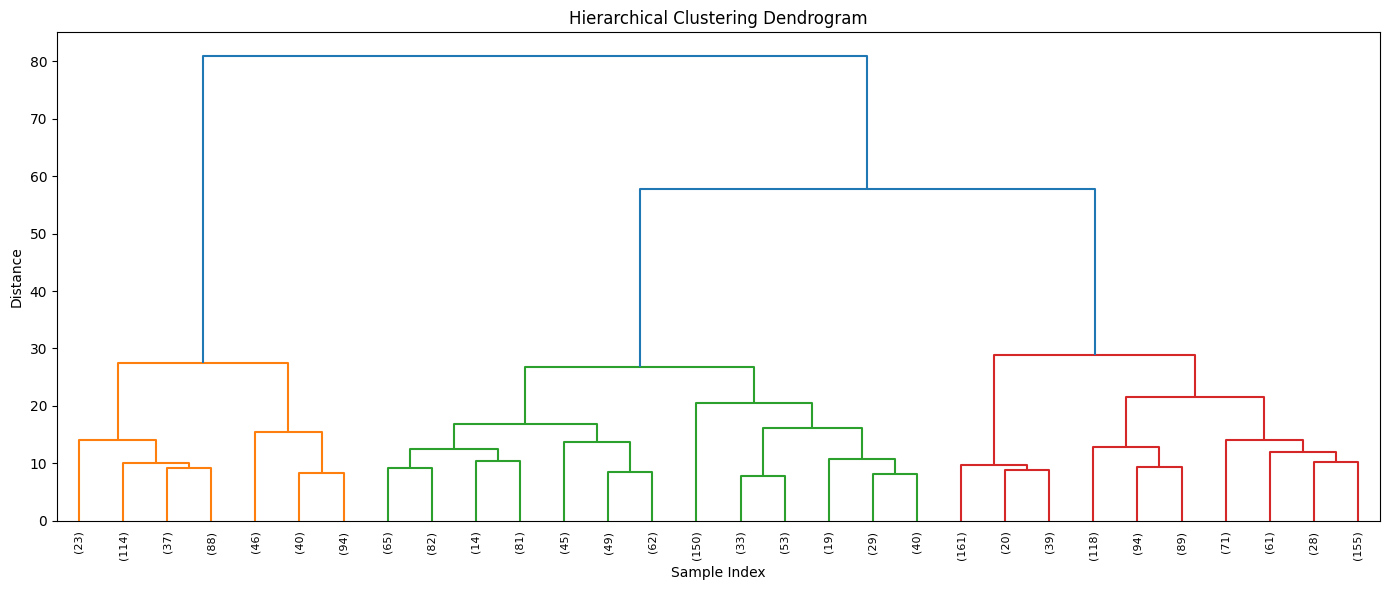

Silhouette Score: 0.1961
Cluster sizes:
0     6989
1     5883
2    10899
3     3628
4     5639
Name: count, dtype: int64
(AgglomerativeClustering(n_clusters=5), array([2, 0, 1, ..., 0, 2, 4], shape=(33038,)))


In [33]:
print(fit_hierarchical(df_saude_rb, 5, method='ward'))

## DBSCAN 

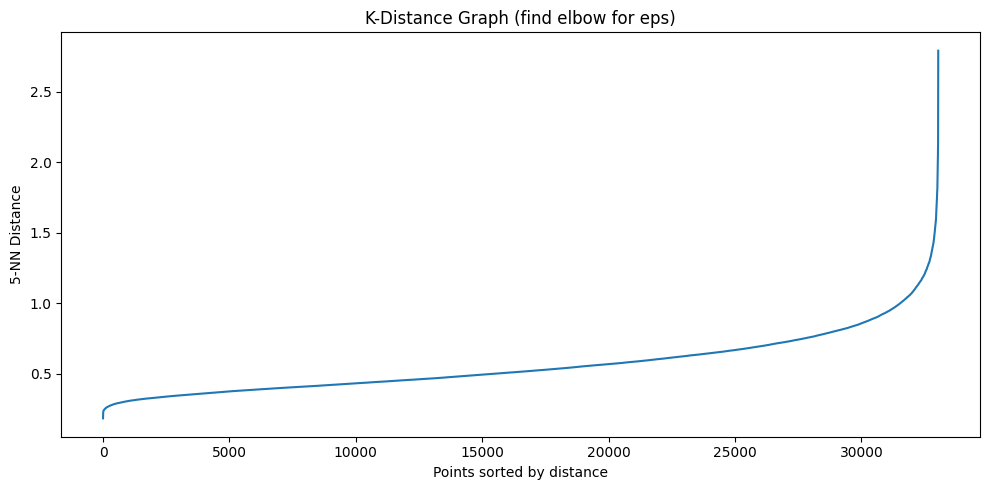

None


In [34]:
print(find_optimal_eps(df_saude_rb, n_neighbors=5))

In [38]:
print(fit_dbscan(df_saude_rb, 2.5, min_samples=5))

Number of clusters: 1
Noise points: 1 (0.00%)
Cluster sizes:
-1        1
 0    33037
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [39]:
print(fit_dbscan(df_saude_rb, 3, min_samples=5)) 

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [40]:
print(fit_dbscan(df_saude_rb, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## Self-Organizing Map (SOM)

In [41]:
# Weights initialization  
initial_weights = _initialize_som_weights(df_saude_rb, map_shape=(30, 30), random_state=42)

# 2. Find the BMU for all customers
all_bmus = [_find_bmu(initial_weights, row) for row in df_saude_rb.values]

# 3. Print the coordinates for the first 5 customers to check the result
print(all_bmus[:5])

[(np.int64(24), np.int64(22)), (np.int64(25), np.int64(20)), (np.int64(27), np.int64(11)), (np.int64(7), np.int64(2)), (np.int64(7), np.int64(2))]


In [42]:
print(_som_learning_rate(initial_lr = 0.1, iteration = 100, n_iterations = 1000))

0.09048374180359596


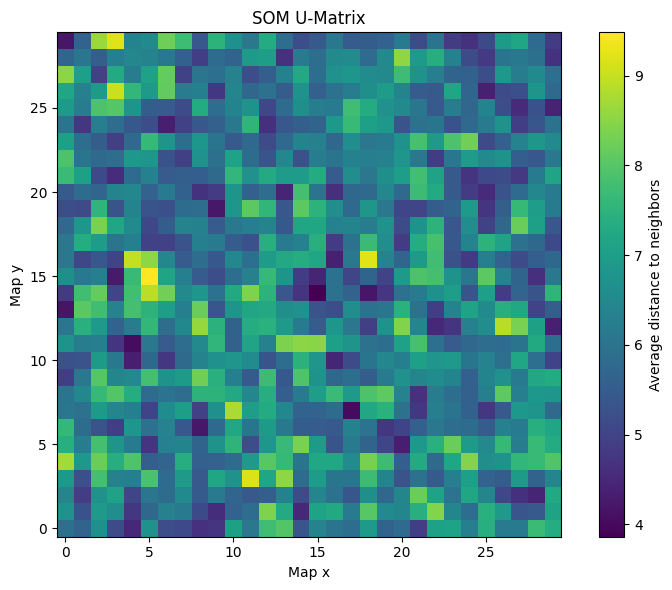

[[5.94685028 5.65902045 6.68643813 5.13901215 4.51814056 6.73215723
  5.19658727 5.09202418 4.67115024 4.69869558 7.05343756 6.08709982
  7.75281507 7.97764914 5.35749228 6.37060391 6.02790395 5.8926894
  6.87646172 5.65000085 5.8324776  4.88488062 7.08471674 7.12059396
  6.28563095 7.41095392 6.19273728 6.18437849 7.69856724 7.34349771]
 [6.71155921 5.28686553 6.8861919  6.60855203 4.77019665 5.75004777
  6.31202768 6.1779768  5.1255851  4.60336755 5.62170176 5.87406471
  8.39023494 7.29776017 4.5161938  7.12243643 7.27409148 6.15681781
  8.02521436 6.54139985 6.44109041 7.40412474 8.43252253 6.43600297
  5.88113219 7.4251319  6.91028125 5.34390777 5.43778943 7.10819923]
 [6.41968805 4.8871906  6.75328127 7.10028257 5.03137887 6.06440726
  5.84703024 6.54971919 5.46163419 6.20881449 5.70301493 5.44127728
  5.56060845 6.34095435 5.15738166 6.42493342 5.96906622 5.37312653
  6.65674347 5.73233546 6.43553933 8.19779196 7.13182455 6.0002735
  7.19671773 6.42729763 5.05107634 4.61178448 4.

In [43]:
print(plot_som_u_matrix(initial_weights))

In [44]:
print(fit_som(df_saude_rb, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, sigma=None, random_state=42, plot_u_matrix=False))


Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100
{'weights': array([[[-3.11130343e-01,  2.39414136e-01,  3.15225804e-01,
          5.07488298e-01,  2.30497953e-01,  1.80389244e+00,
          8.21228644e-01,  3.15600349e-01],
        [-3.13263687e-01,  1.74257041e-01,  3.13849520e-01,
          4.82802581e-01,  2.17724171e-01,  1.68297672e+00,
          9.08515856e-01,  1.16308401e-02],
        [-2.74200686e-01,  3.47574044e-02,  2.79938770e-01,
          4.68315834e-01,  1.33271000e-01,  1.31818350e+00,
          9.90308115e-01, -3.63456216e-01],
        [-2.14300775e-01, -4.10168735e-01,  1.42108758e-01,
          4.72981039e-01, -1.31412734e-01,  6.56450144e-01,
          8.98001399e-01, -5.32019652e-01],
        [-1.04829682e-01, -1.13974395e+00, -8.68855232e-02,
          3.96256512e-01, -3.52069616e-01,  7.37458888e-02,
          6.22462826e-01, -4.29860357e-01],
        [ 5.73322040e-01, -1.83034471e+00, -5.98534806e-01,
          1.36529376e-01, 

In [45]:
print(get_som_cluster_labels(initial_weights, n_clusters=5, random_state=42))

[[0 4 2 2 3 4 2 1 0 2 3 3 2 0 4 0 1 2 3 0 1 0 4 1 4 0 0 3 1 4]
 [4 3 2 3 0 2 1 1 3 2 4 2 0 1 4 2 0 2 0 1 4 0 1 0 0 2 1 1 0 2]
 [3 1 4 1 2 3 2 2 1 0 2 4 0 3 4 4 4 1 2 2 4 3 2 0 1 3 0 0 0 1]
 [3 3 3 4 2 1 4 2 2 3 3 4 0 1 4 0 4 4 0 3 0 0 3 0 0 0 0 2 1 2]
 [1 2 4 0 1 1 2 4 1 0 0 3 2 0 0 4 3 0 1 0 2 0 2 2 3 0 2 1 0 0]
 [3 1 3 1 0 3 0 0 0 3 4 1 3 0 3 2 2 0 3 2 2 2 1 1 2 3 4 1 1 3]
 [3 2 1 1 2 3 4 4 0 0 1 2 1 3 1 1 4 1 0 3 3 1 0 0 4 3 0 0 0 2]
 [0 2 4 1 0 3 1 3 0 0 3 4 0 1 1 4 1 1 2 3 0 4 2 4 0 0 1 3 4 4]
 [3 4 0 0 1 1 1 1 1 3 0 0 3 2 1 1 2 1 0 1 1 1 1 0 3 3 2 1 1 0]
 [1 1 4 2 3 0 2 0 3 0 3 2 4 2 1 3 1 2 2 2 2 1 3 3 0 2 3 1 1 3]
 [1 0 3 4 2 2 4 2 1 3 1 0 2 2 3 1 1 3 3 0 1 4 0 3 3 0 2 4 3 1]
 [0 4 1 1 2 0 4 2 0 2 0 1 0 1 2 0 1 3 1 1 3 1 0 4 1 0 1 2 1 3]
 [3 2 2 1 0 3 4 1 4 0 0 2 1 3 1 0 4 2 2 1 4 2 2 1 0 1 4 1 0 0]
 [3 0 3 1 3 4 4 1 3 1 1 2 2 1 1 0 0 2 1 0 2 2 1 3 1 2 3 0 1 2]
 [3 1 0 0 3 4 3 1 4 3 1 0 4 0 4 4 4 0 1 1 0 3 1 0 4 4 3 2 1 2]
 [1 2 3 1 1 2 0 2 2 2 3 3 1 2 4 4 4 0 0 0 2 4 2 0 2 3 1

In [46]:
print(assign_som_clusters(initial_weights, df_saude_rb,n_clusters=5))

(array([2, 4, 4, ..., 1, 4, 4], shape=(33038,), dtype=int32), array([[0, 4, 2, 2, 3, 4, 2, 1, 0, 2, 3, 3, 2, 0, 4, 0, 1, 2, 3, 0, 1, 0,
        4, 1, 4, 0, 0, 3, 1, 4],
       [4, 3, 2, 3, 0, 2, 1, 1, 3, 2, 4, 2, 0, 1, 4, 2, 0, 2, 0, 1, 4, 0,
        1, 0, 0, 2, 1, 1, 0, 2],
       [3, 1, 4, 1, 2, 3, 2, 2, 1, 0, 2, 4, 0, 3, 4, 4, 4, 1, 2, 2, 4, 3,
        2, 0, 1, 3, 0, 0, 0, 1],
       [3, 3, 3, 4, 2, 1, 4, 2, 2, 3, 3, 4, 0, 1, 4, 0, 4, 4, 0, 3, 0, 0,
        3, 0, 0, 0, 0, 2, 1, 2],
       [1, 2, 4, 0, 1, 1, 2, 4, 1, 0, 0, 3, 2, 0, 0, 4, 3, 0, 1, 0, 2, 0,
        2, 2, 3, 0, 2, 1, 0, 0],
       [3, 1, 3, 1, 0, 3, 0, 0, 0, 3, 4, 1, 3, 0, 3, 2, 2, 0, 3, 2, 2, 2,
        1, 1, 2, 3, 4, 1, 1, 3],
       [3, 2, 1, 1, 2, 3, 4, 4, 0, 0, 1, 2, 1, 3, 1, 1, 4, 1, 0, 3, 3, 1,
        0, 0, 4, 3, 0, 0, 0, 2],
       [0, 2, 4, 1, 0, 3, 1, 3, 0, 0, 3, 4, 0, 1, 1, 4, 1, 1, 2, 3, 0, 4,
        2, 4, 0, 0, 1, 3, 4, 4],
       [3, 4, 0, 0, 1, 1, 1, 1, 1, 3, 0, 0, 3, 2, 1, 1, 2, 1, 0, 1, 1, 1,
        

## Clustering with MinMax Scaler

## K-Means 

k=2 | Inertia: 7550.73 | Silhouette: 0.2132
k=3 | Inertia: 6072.89 | Silhouette: 0.2460
k=4 | Inertia: 4816.02 | Silhouette: 0.2585
k=5 | Inertia: 4325.78 | Silhouette: 0.2393
k=6 | Inertia: 3965.69 | Silhouette: 0.2416
k=7 | Inertia: 3728.74 | Silhouette: 0.2151
k=8 | Inertia: 3526.64 | Silhouette: 0.2048
k=9 | Inertia: 3332.38 | Silhouette: 0.2070
k=10 | Inertia: 3160.83 | Silhouette: 0.2095


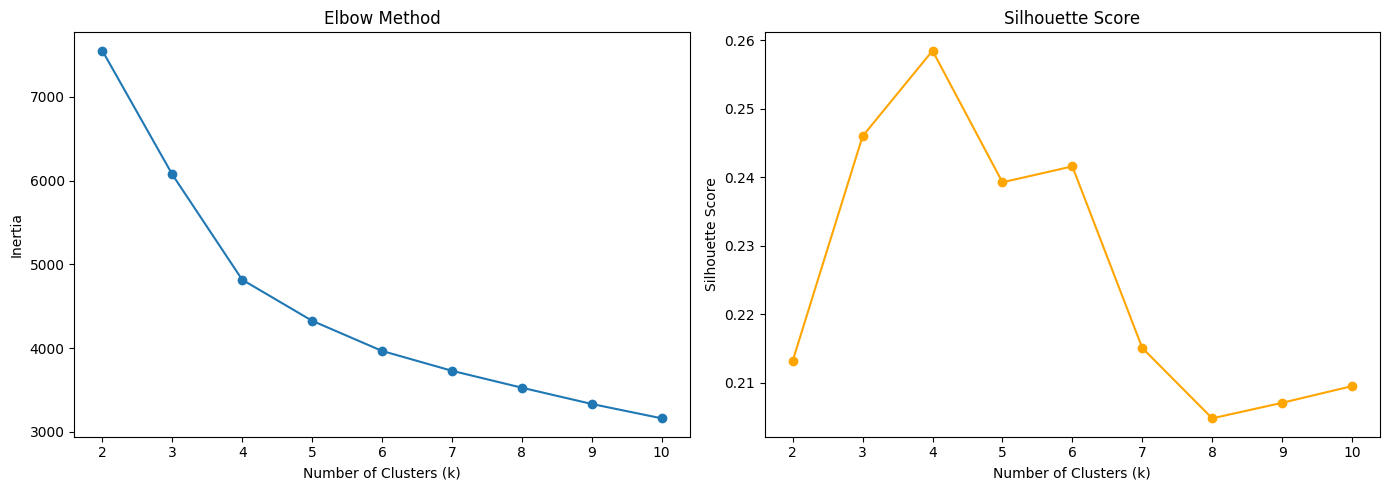

In [47]:
inertias, silhouette_scores = find_optimal_k(df_saude_mm)

### K-Means

In [48]:
"""# Determine best k from previous search if available, otherwise default to 5
try:
    ks = list(range(2, 2 + len(silhouette_scores)))
    best_k = ks[int(np.argmax(silhouette_scores))]
except Exception:
    best_k = 5

print(f"Selected k: {best_k}")"""

'# Determine best k from previous search if available, otherwise default to 5\ntry:\n    ks = list(range(2, 2 + len(silhouette_scores)))\n    best_k = ks[int(np.argmax(silhouette_scores))]\nexcept Exception:\n    best_k = 5\n\nprint(f"Selected k: {best_k}")'

In [49]:
print(fit_kmeans(df_saude_mm, 5))

Silhouette Score: 0.2393
Cluster sizes:
0    6365
1    7429
2    4131
3    9349
4    5764
Name: count, dtype: int64
                                  cluster_0  cluster_1  cluster_2  cluster_3  \
lifetime_spend_vegetables          0.544535   0.179083   0.091656   0.144014   
lifetime_spend_meat                0.521661   0.844835   0.811605   0.816588   
lifetime_spend_fish                0.513558   0.806054   0.774392   0.769332   
lifetime_spend_alcohol_drinks      0.659163   0.736268   0.783009   0.737146   
lifetime_spend_nonalcohol_drinks   0.800074   0.784077   0.761410   0.749610   
lifetime_spend_videogames          0.598007   0.650669   0.726136   0.618210   
typical_hour                       0.393285   0.172763   0.785590   0.219602   
age                                0.537402   0.737707   0.239744   0.221552   

                                  cluster_4  
lifetime_spend_vegetables          0.111846  
lifetime_spend_meat                0.830222  
lifetime_spend_fish      

# MeanShift

In [66]:
mean_shift_mm = MeanShift(bin_seeding=True)
labels_ms_mm = mean_shift_mm.fit_predict(df_saude_mm)
print("MinMax Scaler MeanShift cluster count:", len(np.unique(labels_ms_mm)))
if len(np.unique(labels_ms_mm)) > 1:
    print(f"MinMax Scaler MeanShift silhouette: {silhouette_score(df_saude_mm, labels_ms_mm):.4f}")
else:
    print("MinMax Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_mm).value_counts().sort_index())

MinMax Scaler MeanShift cluster count: 1
MinMax Scaler MeanShift silhouette: not defined (single cluster)
0    33038
Name: count, dtype: int64


## Hierarchical Clustering

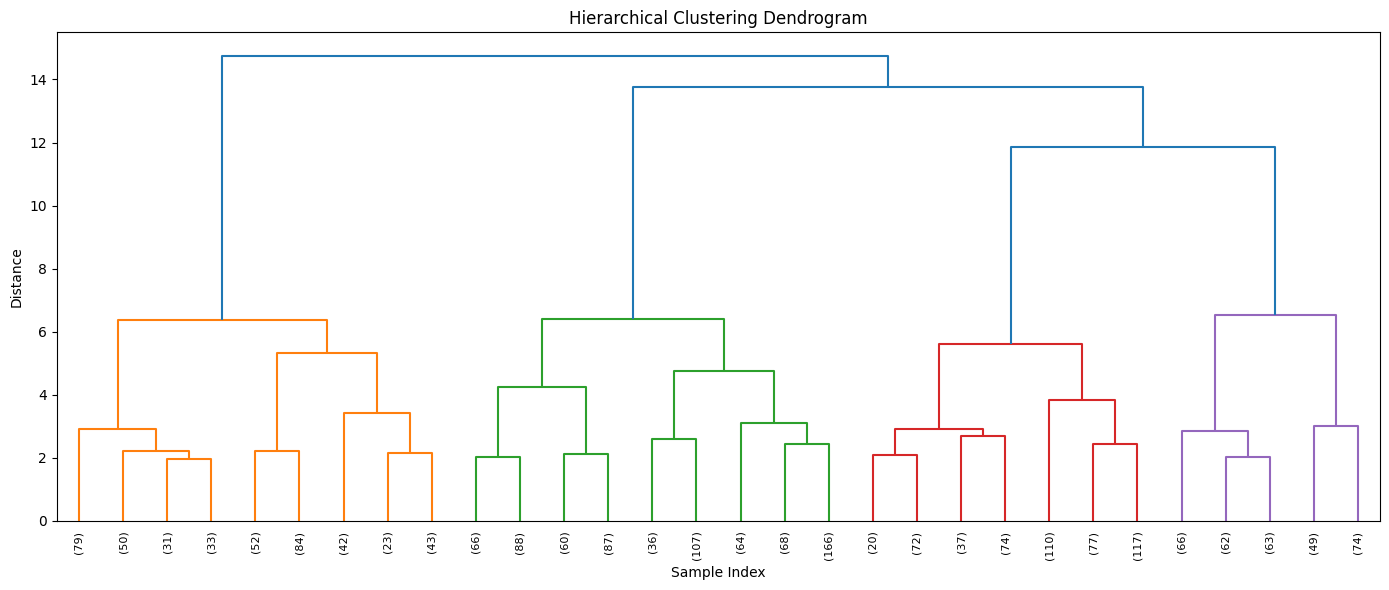

Silhouette Score: 0.1927
Cluster sizes:
0    7055
1    6803
2    5863
3    8311
4    5006
Name: count, dtype: int64
(AgglomerativeClustering(n_clusters=5), array([0, 0, 3, ..., 0, 1, 3], shape=(33038,)))


In [50]:
print(fit_hierarchical(df_saude_mm, 5, method='ward'))

## DBSCAN 

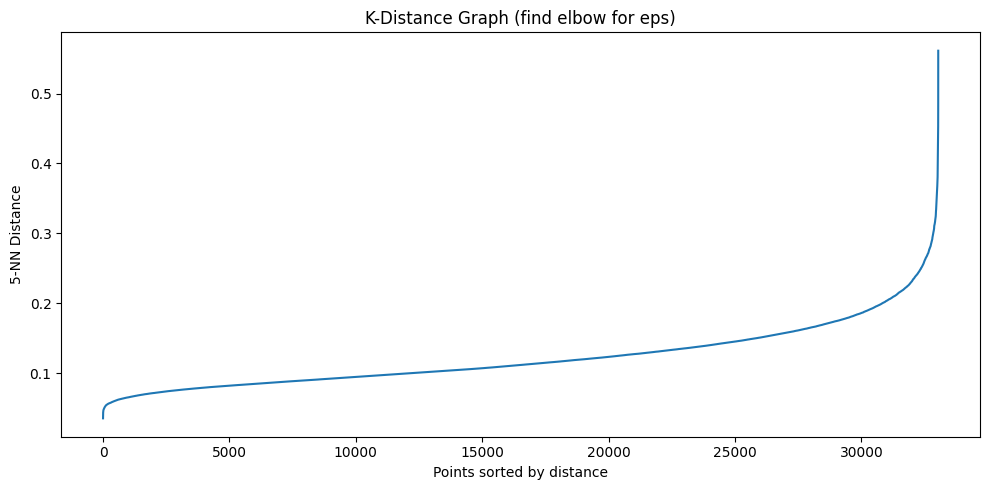

None


In [51]:
print(find_optimal_eps(df_saude_mm, n_neighbors=5))

In [52]:
print(fit_dbscan(df_saude_mm, 2.5, min_samples=5)) 

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [53]:
print(fit_dbscan(df_saude_mm, 3, min_samples=5)) 

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [54]:
print(fit_dbscan(df_saude_mm, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## Self-Organizing Map (SOM)

In [55]:
# Weights initialization  
initial_weights = _initialize_som_weights(df_saude_mm, map_shape=(30, 30), random_state=42)

# 2. Find the BMU for all customers
all_bmus = [_find_bmu(initial_weights, row) for row in df_saude_mm.values]

# 3. Print the coordinates for the first 5 customers to check the result
print(all_bmus[:5])

[(np.int64(15), np.int64(24)), (np.int64(3), np.int64(3)), (np.int64(19), np.int64(6)), (np.int64(14), np.int64(5)), (np.int64(7), np.int64(11))]


In [56]:
print(_som_learning_rate(initial_lr = 0.1, iteration = 100, n_iterations = 1000))

0.09048374180359596


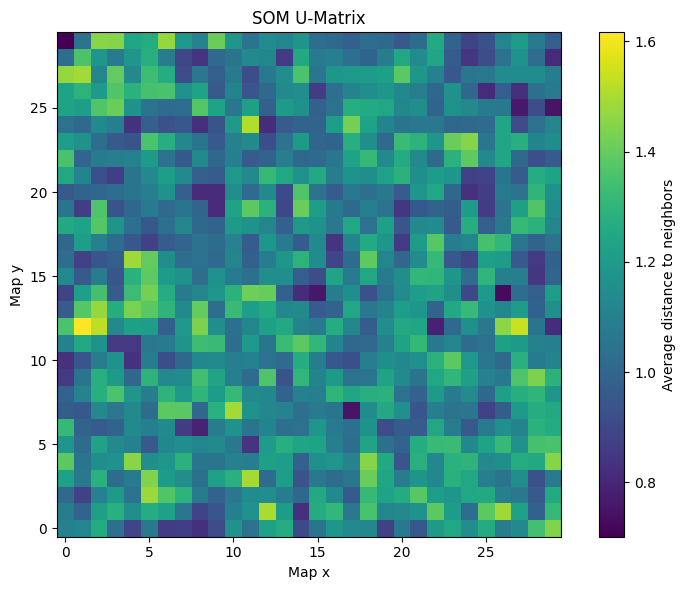

[[1.09857628 1.12226389 1.26356607 1.03832855 0.89315876 1.07252776
  0.85993347 0.87061304 0.82507496 0.91541187 1.1651017  1.04391304
  1.22422729 1.26809714 0.90447874 1.05458481 1.18094153 1.14050122
  1.12385433 0.87955289 1.06838292 0.9548612  1.19230985 1.24529549
  1.15716354 1.26437655 1.08690254 1.14038255 1.34275073 1.44391612]
 [1.08421239 0.99364317 1.22026548 1.28180523 1.15839505 1.26640213
  1.22349822 1.06149512 0.88956339 0.94601039 1.09620334 1.16563314
  1.49883814 1.2057522  0.82675829 1.26566402 1.30880226 1.06454313
  1.35223265 1.11805298 1.13336356 1.1723912  1.38753774 1.20318523
  1.02877778 1.38762019 1.48528087 1.22340367 0.98672456 1.31448957]
 [1.01770237 0.87981156 1.10288669 1.20080715 1.05148888 1.47812447
  1.36741007 1.2919679  1.08227343 0.99044087 1.06504895 1.14740167
  1.14888034 1.08440167 1.00909763 1.25624913 1.13943932 0.95956795
  1.31377712 1.2318797  1.263521   1.37890466 1.2147752  1.18732224
  1.24536034 1.25757924 1.09293263 1.06888686 

In [57]:
print(plot_som_u_matrix(initial_weights))

In [58]:
print(fit_som(df_saude_mm, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, sigma=None, random_state=42, plot_u_matrix=False))

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100
{'weights': array([[[0.58426885, 0.52130195, 0.53739358, 0.68320963, 0.78511579,
         0.64585495, 0.68905056, 0.6521975 ],
        [0.59176153, 0.51777112, 0.52563863, 0.69225289, 0.7877229 ,
         0.64142229, 0.60947753, 0.52709136],
        [0.57445383, 0.52948232, 0.5087357 , 0.68140575, 0.79714422,
         0.63297646, 0.49352968, 0.38552347],
        [0.53854361, 0.52583659, 0.50617643, 0.65149083, 0.79962657,
         0.61929379, 0.33013014, 0.27683771],
        [0.45790003, 0.54217908, 0.55571465, 0.62323359, 0.7931153 ,
         0.61513468, 0.17293191, 0.21032661],
        [0.29240561, 0.67518359, 0.66616821, 0.61724584, 0.76022742,
         0.62339853, 0.11269725, 0.16881894],
        [0.13343707, 0.78827131, 0.708769  , 0.66387844, 0.72280067,
         0.61293622, 0.12038691, 0.13494896],
        [0.08228233, 0.78939969, 0.67344844, 0.72295919, 0.70302398,
         0.58301049, 0.15438974,

In [59]:
print(get_som_cluster_labels(initial_weights, n_clusters=5, random_state=42))

[[1 4 0 1 1 0 3 3 1 1 2 4 4 1 4 1 4 1 3 4 3 1 0 2 1 1 4 0 3 0]
 [1 0 1 1 4 3 3 0 2 1 4 1 4 2 0 3 2 4 2 3 0 1 2 4 1 1 3 2 0 4]
 [1 0 4 0 1 4 0 4 3 2 0 4 1 2 4 0 0 3 1 3 1 4 1 0 0 3 4 1 4 2]
 [2 1 2 1 1 3 1 0 0 4 2 3 1 3 0 1 1 4 2 0 2 4 3 1 2 2 1 1 0 0]
 [3 1 3 1 2 3 1 4 0 2 2 1 0 2 2 0 4 2 3 1 1 2 4 0 3 1 4 3 4 1]
 [2 0 2 3 1 1 1 0 4 2 0 2 2 1 4 4 4 1 2 2 1 4 2 3 1 2 0 0 3 4]
 [4 0 0 2 1 3 4 1 1 1 0 1 2 4 4 0 1 0 2 2 4 4 2 1 1 1 2 2 1 0]
 [2 0 0 3 4 3 3 0 2 4 2 0 1 2 2 1 3 0 3 1 4 4 4 1 2 2 2 3 1 1]
 [3 0 1 4 2 3 0 2 3 4 1 1 3 0 3 0 1 3 2 2 3 4 3 2 2 3 4 0 2 2]
 [3 3 4 1 1 2 0 2 1 2 3 4 1 0 2 4 0 4 4 1 1 3 2 0 4 0 2 2 3 0]
 [0 2 4 4 0 1 0 3 0 1 3 1 4 0 4 3 2 1 2 2 0 4 1 3 4 2 0 0 1 2]
 [4 0 3 2 4 1 0 0 2 1 2 3 1 3 0 1 2 2 2 0 1 3 0 1 2 1 3 1 3 3]
 [3 4 1 2 1 4 1 3 0 2 1 1 0 4 2 4 0 1 4 0 0 1 3 3 0 0 0 3 1 1]
 [2 2 2 0 4 1 0 3 2 3 0 3 4 2 3 1 0 1 4 0 1 4 3 3 3 0 2 1 0 3]
 [4 3 4 0 4 0 3 4 4 1 3 2 1 1 4 0 3 0 4 0 1 3 3 4 4 0 1 1 2 4]
 [3 1 4 0 3 1 2 1 1 0 3 4 3 4 0 0 0 2 2 2 1 0 4 1 0 3 2

In [60]:
print(assign_som_clusters(initial_weights, df_saude_mm,n_clusters=5))

(array([0, 1, 2, ..., 0, 0, 0], shape=(33038,), dtype=int32), array([[1, 4, 0, 1, 1, 0, 3, 3, 1, 1, 2, 4, 4, 1, 4, 1, 4, 1, 3, 4, 3, 1,
        0, 2, 1, 1, 4, 0, 3, 0],
       [1, 0, 1, 1, 4, 3, 3, 0, 2, 1, 4, 1, 4, 2, 0, 3, 2, 4, 2, 3, 0, 1,
        2, 4, 1, 1, 3, 2, 0, 4],
       [1, 0, 4, 0, 1, 4, 0, 4, 3, 2, 0, 4, 1, 2, 4, 0, 0, 3, 1, 3, 1, 4,
        1, 0, 0, 3, 4, 1, 4, 2],
       [2, 1, 2, 1, 1, 3, 1, 0, 0, 4, 2, 3, 1, 3, 0, 1, 1, 4, 2, 0, 2, 4,
        3, 1, 2, 2, 1, 1, 0, 0],
       [3, 1, 3, 1, 2, 3, 1, 4, 0, 2, 2, 1, 0, 2, 2, 0, 4, 2, 3, 1, 1, 2,
        4, 0, 3, 1, 4, 3, 4, 1],
       [2, 0, 2, 3, 1, 1, 1, 0, 4, 2, 0, 2, 2, 1, 4, 4, 4, 1, 2, 2, 1, 4,
        2, 3, 1, 2, 0, 0, 3, 4],
       [4, 0, 0, 2, 1, 3, 4, 1, 1, 1, 0, 1, 2, 4, 4, 0, 1, 0, 2, 2, 4, 4,
        2, 1, 1, 1, 2, 2, 1, 0],
       [2, 0, 0, 3, 4, 3, 3, 0, 2, 4, 2, 0, 1, 2, 2, 1, 3, 0, 3, 1, 4, 4,
        4, 1, 2, 2, 2, 3, 1, 1],
       [3, 0, 1, 4, 2, 3, 0, 2, 3, 4, 1, 1, 3, 0, 3, 0, 1, 3, 2, 2, 3, 4,
        

## Compare all models 

## TSNE


KMeans k=2 silhouette: 0.2138 (2 labels)
KMeans k=3 silhouette: 0.2438 (3 labels)
KMeans k=4 silhouette: 0.2553 (4 labels)
KMeans k=5 silhouette: 0.2346 (5 labels)
KMeans k=6 silhouette: 0.2399 (6 labels)
KMeans k=7 silhouette: 0.2120 (7 labels)
MeanShift: silhouette not defined (only 1 cluster(s))
Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100
SOM silhouette: 0.0372 (100 labels)

Best model: KMeans k=4 with silhouette 0.2553


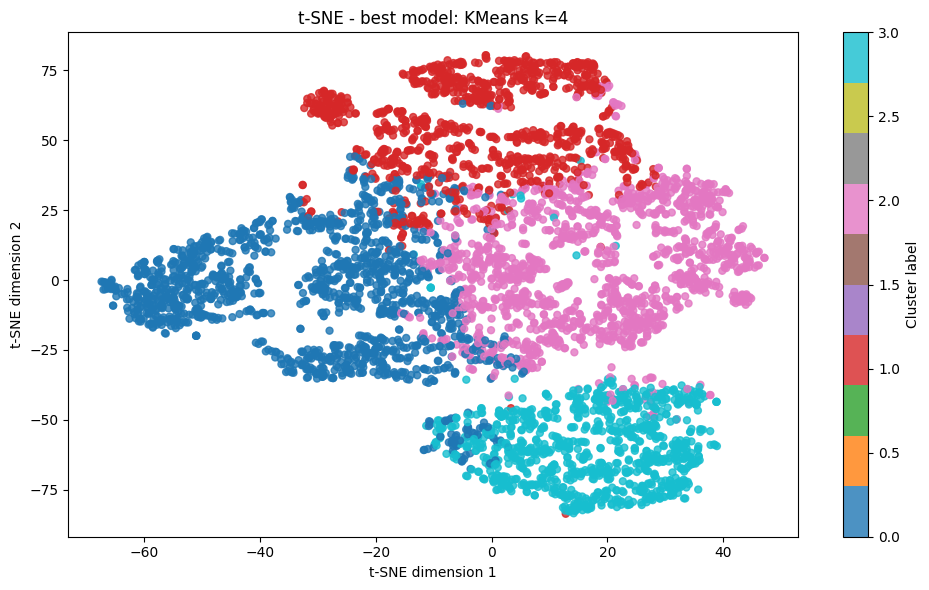

In [68]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, MeanShift
import matplotlib.pyplot as plt

sample_size = min(len(df_saude_mm), 5000)
df_sample = df_saude_mm.sample(n=sample_size, random_state=42)


def plot_tsne_labels(X_embedded, labels, title):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='tab10', s=25, alpha=0.8)
    plt.colorbar(scatter, label='Cluster label')
    plt.title(title)
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.tight_layout()
    plt.show()


def evaluate_model(name, labels):
    unique_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if unique_clusters <= 1:
        print(f"{name}: silhouette not defined (only {unique_clusters} cluster(s))")
        return None
    score = silhouette_score(df_sample, labels)
    print(f"{name} silhouette: {score:.4f} ({len(set(labels))} labels)")
    return score

results = []
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(df_sample)
    score = evaluate_model(f"KMeans k={k}", labels)
    if score is not None:
        results.append((score, f"KMeans k={k}", labels))

mean_shift_model = MeanShift(bin_seeding=True)
labels_ms = mean_shift_model.fit_predict(df_sample)
score_ms = evaluate_model("MeanShift", labels_ms)
if score_ms is not None:
    results.append((score_ms, "MeanShift", labels_ms))

som_result = fit_som(df_sample, map_shape=(10, 10), n_iterations=1000,
                     learning_rate=0.5, sigma=None, random_state=42, plot_u_matrix=False)
labels_som = som_result['labels']
score_som = evaluate_model("SOM", labels_som)
if score_som is not None:
    results.append((score_som, "SOM", labels_som))

if not results:
    raise ValueError("No valid model for t-SNE was found")

best_score, best_model_name, best_labels = max(results, key=lambda x: x[0])
print(f"\nBest model: {best_model_name} with silhouette {best_score:.4f}")

perplexity = min(30, max(2, (sample_size - 1) // 3))
tsne_model = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca')
X_tsne = tsne_model.fit_transform(df_sample)

plot_tsne_labels(X_tsne, best_labels, f"t-SNE - best model: {best_model_name}")

In [69]:
print('abcd')

abcd
